<a href="https://colab.research.google.com/github/luffy-loop/Machine_Learning/blob/main/LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# =====================================================
# 1. LOAD DATASET
# =====================================================

data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
class_names = data.target_names

In [2]:
# 2. TRAIN-TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [3]:
# 3. GINI TREE


dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

dt_gini.fit(X_train, y_train)

gini_train = dt_gini.score(X_train, y_train)
gini_test = dt_gini.score(X_test, y_test)

print("\nGINI TREE")
print("Depth:", dt_gini.get_depth())
print("Training Accuracy:", gini_train)
print("Testing Accuracy:", gini_test)


GINI TREE
Depth: 7
Training Accuracy: 1.0
Testing Accuracy: 0.9122807017543859


In [4]:
# 4. ENTROPY TREE
# =====================================================

dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_entropy.fit(X_train, y_train)

entropy_train = dt_entropy.score(X_train, y_train)
entropy_test = dt_entropy.score(X_test, y_test)

print("\nENTROPY TREE")
print("Depth:", dt_entropy.get_depth())
print("Training Accuracy:", entropy_train)
print("Testing Accuracy:", entropy_test)


ENTROPY TREE
Depth: 6
Training Accuracy: 1.0
Testing Accuracy: 0.9122807017543859


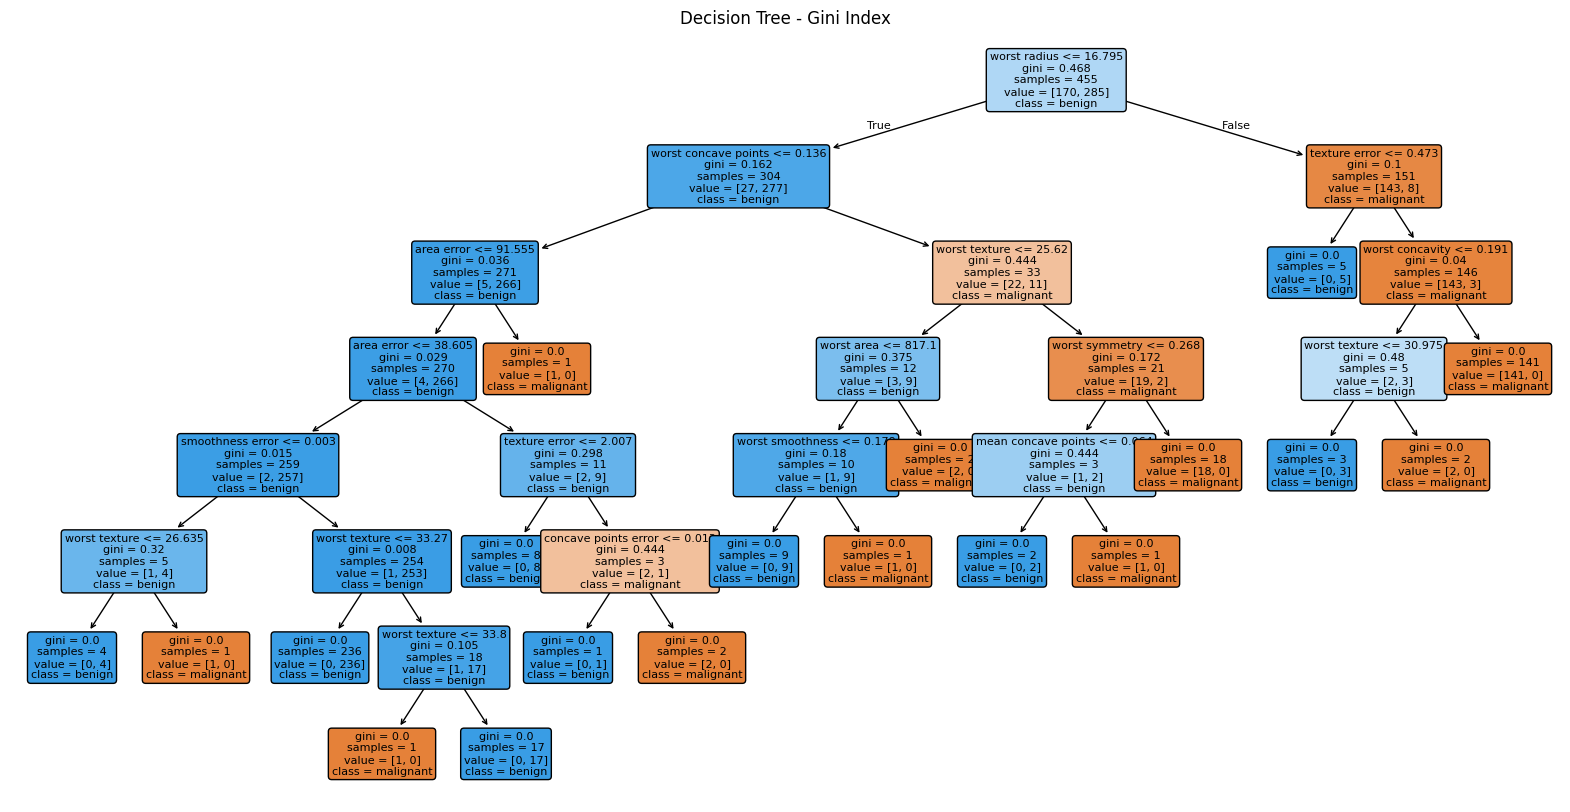

In [5]:
# 5. VISUALIZE GINI TREE
# =====================================================

plt.figure(figsize=(20, 10))

plot_tree(
    dt_gini,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree - Gini Index")
plt.show()

In [6]:
# 6. COST COMPLEXITY PRUNING


path = dt_gini.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

trees = []

for alpha in ccp_alphas:

    model = DecisionTreeClassifier(
        criterion='gini',
        ccp_alpha=alpha,
        random_state=42
    )

    model.fit(X_train, y_train)

    trees.append(model)

In [7]:
# 7. EVALUATE PRUNED TREES
# =====================================================

train_scores = []
test_scores = []
tree_depths = []

for model in trees:

    train_scores.append(
        model.score(X_train, y_train)
    )

    test_scores.append(
        model.score(X_test, y_test)
    )

    tree_depths.append(
        model.get_depth()
    )

In [8]:
# 8. PRUNING RESULTS
# =====================================================

pruning_results = pd.DataFrame({
    'CCP Alpha': ccp_alphas,
    'Depth': tree_depths,
    'Training Accuracy': train_scores,
    'Testing Accuracy': test_scores
})

print("\nPRUNING RESULTS")
print(pruning_results)


PRUNING RESULTS
    CCP Alpha  Depth  Training Accuracy  Testing Accuracy
0    0.000000      7           1.000000          0.912281
1    0.002181      6           0.995604          0.921053
2    0.002866      5           0.991209          0.938596
3    0.002930      5           0.989011          0.938596
4    0.003956      4           0.986813          0.938596
5    0.004251      4           0.984615          0.938596
6    0.005024      4           0.982418          0.938596
7    0.005275      4           0.978022          0.929825
8    0.005934      3           0.973626          0.938596
9    0.007641      3           0.971429          0.938596
10   0.014390      2           0.958242          0.894737
11   0.020386      2           0.947253          0.903509
12   0.054334      1           0.923077          0.921053
13   0.326617      0           0.626374          0.631579
